# The delta planning vector

The phone rings at 6 a.m. The cooling-water supply is de-rated 0.8 MW for the
day, or the supplier is 5 kmol/h short, or the customer has tightened the
product specification from 98.5% to 99.0%. What you want is not a number. You
want **three setpoints**: how far to move the feed valve, the reactor
temperature, and the purge.

The shadow price answers the wrong question. It says the tightened
specification costs `$18.04/h` at first order — 0.7% of a `$2,731.50/h` margin,
so small it is easy to conclude nothing needs to happen. But holding the old
setpoints ships off-spec product, and the plan that *defends* that 0.7% moves
the purge valve **+72%** and the recycle compressor **−39%**. The price is
flat. The plan is not.

The plan is a derivative too. If $p$ is the disrupted parameter, then

$$\Delta x^\star \approx \frac{\partial x^\star}{\partial p} \Delta p$$

is a vector of setpoint changes, and it comes out of the same held KKT
factorization the base solve already left behind — one back-solve per
parameter, no re-solve. Four columns of that Jacobian cost **under a tenth of a
millisecond**, against a couple of milliseconds for a single re-solve, and each
disruption after that is a matrix times a vector: **well under a
microsecond**. Every disruption in this notebook is answered
without solving anything.

That is the easy half. The hard half is that **the delta is sometimes a lie,
and it lies while reporting success**. Ask this plant for the tightened
specification and the linear plan hands back a state vector whose purity entry
reads exactly 0.990000. Run the plant at its three setpoints and the product
comes out at **0.988844** — off-spec, into a tank, at line rate. Nothing in the
answer says so.

Something else does. `solution_report` runs a ratio test on the same
factorization and returns `alpha`, the fraction of the requested move the
active set survives. For that disruption `alpha = 0.578`: the reactor hits its
metallurgical limit **57.8% of the way** into the move, and the linear plan is a
linearization of a problem that has already changed shape. The warning is
available *before* the plan is, at no extra cost.

This notebook builds the playbook and then breaks it, on purpose:

* a nonlinear reactor–separator–recycle train, four exogenous parameters, and
  the Jacobian $\partial x^\star/\partial p$ from four back-solves, checked
  against finite differences;
* **the counterintuitive mover** — a cooling de-rate whose largest fractional
  move is the *purge valve*, which no operator would touch, and a purity
  specification whose largest move is on a compressor it never mentions;
* **when the delta is a lie** — the off-spec plan above, and a winter plan
  that quietly books `$40/h` of profit on 3.31 kmol/h of feed the contract does
  not allow;
* **the corrector** — `corrector_iter=2` recovers the true answer to six
  digits on one disruption, and cannot help at all on another, for a reason
  worth knowing;
* **deltas do not compose** — two plans that are each valid alone sum to a plan
  that asks the reactor to run 2.96 K above its metallurgical wall;
* **the fractional plan** — the DCS accepts 0.5 K, not 0.5124 K, and rounding
  the wrong way ships an alarm; rounding by the sign pattern of the binding
  rows costs `$5.79/h` against the true optimum, where the experienced
  operator's heuristic costs `$13.59/h`.

Everything runs against the pure-Python `pounce.sensitivity` layer:
`SensSession`, `solution`, `solution_report`, `active_set_changes`. Its
companion, [`40_shadow_prices_expire.ipynb`](40_shadow_prices_expire.ipynb),
is about how far a *price* holds; this one is about the *plan*.

In [1]:
import platform, subprocess, warnings
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
import pounce
from pounce.sensitivity import (
    SensSession, NlBridge, solution, solution_report, active_set_changes,
)

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

python        3.12.11
pounce-solver 0.11.0
commit        f40774c7952a


## 1. The plant

A single reaction train. Fresh feed $F$ (mostly reactant A, with a heavy
impurity fraction $z_w$) joins a recycle stream and enters a stirred reactor at
temperature $T$. Two reactions compete for A:

$$\mathrm{A}\ \xrightarrow{\ k_1(T)\ }\ \mathrm{P}\ (\text{product}),
\qquad
\mathrm{A}\ \xrightarrow{\ k_2(T)\ }\ \mathrm{W}\ (\text{waste}),$$

with $E_2 > E_1$, so heat buys **conversion** and costs **selectivity**. The
reactor effluent goes to a separator: product P leaves as the sale stream,
carrying a fraction $\phi$ of whatever W is present; unconverted A and the rest
of the W go back around the loop. A purge valve bleeds a fraction $y$ of the
recycle to keep W from accumulating without bound.

Three things the operator sets:

| | | |
|---|---|---|
| $F$ | fresh feed rate | kmol/h |
| $T$ | reactor temperature | K |
| $y$ | purge fraction | — |

Four things the world sets, and the subject of this notebook:

| | | |
|---|---|---|
| $F_{\max}$ | the supply contract | kmol/h |
| $Q_{\max}$ | condenser duty available | MW |
| $\text{pur}_{\min}$ | the customer's specification | — |
| $z_w$ | heavy fraction in the delivered feed | — |

The plan maximizes margin — product sold, less feed, cooling, and the
compression cost of everything sent around the loop:

$$\max_{F,T,y}\ \ 95 P - 52 F - 22 Q - 0.35 R_c$$

subject to the reactor and separator balances, $F \le F_{\max}$,
$Q \le Q_{\max}$, $\text{pur} \ge \text{pur}_{\min}$, and a metallurgical
limit $T \le 555$ K on the reactor wall.

The recycle is what makes this interesting. Every balance is coupled to every
other through the loop, so no knob has a local effect, and the answer to
"which valve do I move" is genuinely not guessable.

In [2]:
# --- kinetics (reduced Arrhenius about T0, so the exponents stay O(1)) ----
T0, G1, G2 = 520.0, 13.9, 25.4          # K;  E/(R T0) for  A->P  and  A->W
K1_0, K2_0 = 1.20, 0.0372               # 1/h at T0   =>  S(T0) = 0.970
V, PHI     = 60.0, 0.020                # kmol holdup;  W carried into product
DH1, DH2   = 0.060, 0.110               # MW per kmol/h of A through each path

# --- economics ($/h) -----------------------------------------------------
PR_P, PR_A = 95.0, 52.0                 # $/kmol of product sold, feed bought
PR_Q, PR_RC = 22.0, 0.35                # $/MW-h of cooling, $/kmol recycled

SET    = ["F", "T", "y"]                            # what an operator sets
STATE  = ["a", "w", "P", "Q", "Rc", "pur"]          # what the plant then does
PARAM  = ["F_max", "Q_max", "pur_min", "z_w"]       # what the world does to you
UNIT   = {"F": "kmol/h", "T": "K", "y": "-", "a": "kmol/h", "w": "kmol/h",
          "P": "kmol/h", "Q": "MW", "Rc": "kmol/h", "pur": "-",
          "F_max": "kmol/h", "Q_max": "MW", "pur_min": "-", "z_w": "-"}

VNAMES = SET + STATE + PARAM
RNAMES = ["pin_F_max", "pin_Q_max", "pin_pur_min", "pin_z_w",
          "bal_A", "bal_W", "def_P", "def_Q", "def_Rc", "def_pur",
          "feed_cap", "cool_cap", "purity_spec"]
PIN    = {p: i for i, p in enumerate(PARAM)}        # parameter -> its pin row
CAP    = {"F_max": "feed_cap", "Q_max": "cool_cap", "pur_min": "purity_spec"}

PAR0 = np.array([100.0, 5.2, 0.985, 0.004])         # today's world
X0   = [90.0, 530.0, 0.06, 200.0, 25.0, 60.0, 4.0, 200.0, 0.99]   # a start

T_UB = 555.0            # metallurgical limit on the reactor wall
print(f"{'parameter':10s}{'value':>10s}  {'':10s}what moves it")
for p, v, what in zip(PARAM, PAR0,
                      ["the supply contract you signed",
                       "cooling-water temperature; summer vs winter",
                       "the customer's product specification",
                       "the heavy fraction your supplier ships"]):
    print(f"{p:10s}{v:10.4g}  {UNIT[p]:10s}{what}")

parameter      value            what moves it
F_max            100  kmol/h    the supply contract you signed
Q_max            5.2  MW        cooling-water temperature; summer vs winter
pur_min        0.985  -         the customer's product specification
z_w            0.004  -         the heavy fraction your supplier ships


### Parameters are pinned rows

`pounce.sensitivity` addresses a parameter by the **equality row that pins
it**. There is no `make_parameter` in the Python layer: each parameter enters
as a variable and is pinned by an equality, and that row's index is the
parameter's handle. So $F_{\max}$, $Q_{\max}$, $\text{pur}_{\min}$ and $z_w$
are variables 9–12, pinned by rows 0–3, and the capacity rows are written
against the *variables*:

$$F - F_{\max} \le 0,\qquad Q - Q_{\max} \le 0,\qquad
\text{pur}_{\min} - \text{pur} \le 0 .$$

$z_w$ has no capacity row at all — it appears inside the balances. That is
deliberate: it shows the pin-row handle works for a parameter that is not a
"capacity" in any sense, which is most parameters.

Two conventions that matter downstream:

* `bound_relax_factor = 0.0`. POUNCE relaxes bounds by a hair by default, and
  the activity accessors refuse to classify a solve whose bounds were relaxed —
  a coordinate can sit *outside* its bound and "on the bound" stops being a
  well-posed question.
* `solve_for_sensitivity` would build the session in one call, but it discards
  the solve's `info`, and we want `info["mult_g"]`. Its body is six lines, so
  we inline them.

In [3]:
def build(par, x0=X0):
    """The plant model at parameter values `par`, as an NL problem.

    Variables are ordered SET + STATE + PARAM.  Each parameter is a
    variable pinned by an equality row -- that pin row is the handle the
    sensitivity layer perturbs, and there is no `make_parameter` in the
    Python API.
    """
    v = pounce.NlExpr.vars(13)
    F, T, y, a, w, P, Q, Rc, pur = v[:9]
    F_max, Q_max, pur_min, z_w = v[9:]
    ex = pounce.NlExpr.exp

    k1, k2 = K1_0*ex(-G1*(T0/T - 1.0)), K2_0*ex(-G2*(T0/T - 1.0))
    S      = k1/(k1 + k2)                             # selectivity to P
    X      = 1.0 - ex(-(k1 + k2)*V/(a + w))           # per-pass conversion of A
    w_sep  = w + a*X*(1.0 - S)                        # W reaching the separator

    cons = [
        F_max, Q_max, pur_min, z_w,                                # the pins
        a - (1.0 - z_w)*F - (1.0 - y)*a*(1.0 - X),                 # A loop
        w - z_w*F - (1.0 - y)*(1.0 - PHI)*w_sep,                   # W loop
        P  - a*X*S,
        Q  - (DH1*S + DH2*(1.0 - S))*a*X,
        Rc - (1.0 - y)*(a*(1.0 - X) + (1.0 - PHI)*w_sep),
        pur*(P + PHI*w_sep) - P,                                   # purity
        F - F_max,                                                 # feed_cap
        Q - Q_max,                                                 # cool_cap
        pur_min - pur,                                             # purity_spec
    ]
    obj = -(PR_P*P - PR_A*F - PR_Q*Q - PR_RC*Rc)       # minimize -profit
    INF = 1e19
    return pounce.build_nl_problem(
        n=13, objective=obj, constraints=cons,
        g_l=list(par) + [0.0]*6 + [-INF]*3,            # pins are equalities
        g_u=list(par) + [0.0]*6 + [0.0]*3,             # caps are  g <= 0
        x_l=[0.0, 495.0, 0.005, 1.0, 0.0, 0.0, 0.0, 0.0, 0.5] + [-INF]*4,
        x_u=[INF, T_UB, 0.60] + [INF]*6 + [INF]*4,
        x0=list(x0) + list(par), var_names=VNAMES, con_names=RNAMES)


def solve(par, x0=X0):
    """Solve at `par`; return (SensSession, info).

    This is `solve_for_sensitivity` with its body spelled out, so the
    solve's `info` -- which carries the multipliers -- survives.
    """
    nl   = build(par, x0)
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl),
                          lb=nl.x_l, ub=nl.x_u, cl=nl.g_l, cu=nl.g_u)
    prob.add_option("bound_relax_factor", 0.0)   # the sensitivity layer needs it
    prob.add_option("print_level", 0)
    solver  = pounce.Solver(prob)
    x, info = solver.solve(np.asarray(nl.x0))
    sess = SensSession(nl, solver, VNAMES, RNAMES, pins=PIN)
    sess.base_x, sess.base_obj = np.asarray(x, float), float(info["obj_val"])
    return sess, info


def plan(par, x0=X0):
    """The optimal plan and its profit at `par` -- a full re-solve."""
    sess, info = solve(par, x0)
    return sess.base_x, -float(info["obj_val"])

### The plant is not the model

Every claim in this notebook about what a plan *delivers* is checked by running
the setpoints through an independent simulation of the loop — a fixed-point
iteration on the recycle, not the optimizer's algebra — and auditing the
result against the contract, the condenser, the specification, and the
metallurgical limit.

This is the whole reason the notebook can say "the plan is a lie" and mean it.
A linear step returns a full state vector, including entries for `pur` and `Q`.
Those entries are the *linearization's* opinion of what the plant will do. The
audit below is what the plant actually does.

In [4]:
def run_plant(F, T, y, z_w, iters=400):
    """What the plant does at a setpoint triple.

    Closes the two recycle balances by successive substitution.  No
    optimizer and no constraints: this is the plant, not the model.  A
    delta plan ships (F, T, y); everything else is the plant's answer,
    and whether it meets spec is a question, not an assumption.
    """
    k1, k2 = K1_0*np.exp(-G1*(T0/T - 1.0)), K2_0*np.exp(-G2*(T0/T - 1.0))
    S = k1/(k1 + k2)
    a, w = 3.0*F, 0.4*F
    for _ in range(iters):
        X  = 1.0 - np.exp(-(k1 + k2)*V/(a + w))
        an = (1.0 - z_w)*F/(1.0 - (1.0 - y)*(1.0 - X))
        c  = (1.0 - y)*(1.0 - PHI)
        wn = (z_w*F + c*an*X*(1.0 - S))/(1.0 - c)
        a, w = 0.5*(a + an), 0.5*(w + wn)
    X = 1.0 - np.exp(-(k1 + k2)*V/(a + w))
    w_sep = w + a*X*(1.0 - S)
    P, Q  = a*X*S, (DH1*S + DH2*(1.0 - S))*a*X
    Rc    = (1.0 - y)*(a*(1.0 - X) + (1.0 - PHI)*w_sep)
    return dict(a=a, w=w, P=P, Q=Q, Rc=Rc, pur=P/(P + PHI*w_sep),
                profit=PR_P*P - PR_A*F - PR_Q*Q - PR_RC*Rc)


def audit(F, T, y, par):
    """Run the plant at a setpoint triple and check it against every limit.

    The tolerances are what an instrument could see -- 0.1 ppm of purity,
    0.1 kW of duty, 0.1 mol/h of feed, a millikelvin -- not machine epsilon.
    """
    s = run_plant(F, T, y, par[3])
    bad = []
    if s["pur"] < par[2] - 1e-7:
        bad.append(f"OFF-SPEC by {(par[2] - s['pur'])*1e6:,.0f} ppm")
    if s["Q"]   > par[1] + 1e-4:  bad.append(f"COOLING over by {s['Q']-par[1]:.3f} MW")
    if F        > par[0] + 1e-4:  bad.append(f"CONTRACT over by {F-par[0]:.2f} kmol/h")
    if T        > T_UB  + 1e-3:  bad.append(f"METALLURGY over by {T-T_UB:.2f} K")
    s["verdict"] = "; ".join(bad) or "feasible"
    return s

### The base point

Solve at today's parameters. Every claim downstream is vacuous unless the base
point has a specific shape, so the cell asserts it: **cooling and purity
binding** (two active rows to price and to move against), **the feed contract
slack** (a parameter whose column is genuinely zero — that turns out to be a
story of its own), and **$T$ and $y$ strictly interior** (so the plan has room
to move before it hits anything).

In [5]:
sess0, info0 = solve(PAR0)
XB, PB = sess0.base_x, -float(info0["obj_val"])
LAM    = np.asarray(info0["mult_g"])
gB     = np.asarray(sess0.nl.constraints(XB))

print(f"status {info0['status']}    profit  ${PB:,.2f}/h\n")
print(f"{'setpoint':10s}{'value':>12s}   {'':8s}")
for n in SET:
    print(f"{n:10s}{XB[VNAMES.index(n)]:12.4f}   {UNIT[n]}")
print()
for n in STATE:
    print(f"{n:10s}{XB[VNAMES.index(n)]:12.4f}   {UNIT[n]}")
print()
print(f"{'row':14s}{'slack':>12s}{'multiplier':>14s}")
for j, r in enumerate(RNAMES[10:], start=10):
    print(f"{r:14s}{-gB[j]:12.5f}{LAM[j]:14.4f}"
          + ("   BINDING" if abs(gB[j]) < 1e-7 else ""))
print(f"{'T <= ' + str(T_UB):14s}{T_UB - XB[1]:12.5f}")

# every claim below is vacuous without these
assert info0["status"] == 0
assert abs(gB[11]) < 1e-7 and abs(gB[12]) < 1e-7, "cooling and purity must bind"
assert gB[10] < -1e-3,        "the feed contract must be slack at the base"
assert 495.0 + 1e-3 < XB[1] < T_UB - 1e-3, "T must be interior at the base"
assert 0.005 + 1e-4 < XB[2] < 0.60 - 1e-4, "y must be interior at the base"
assert LAM[11] > 1e-6 and LAM[12] > 1e-6,   "both binding rows must price"
print("\nbase point: cooling and purity binding, contract slack, "
      "both setpoints interior")

status 0    profit  $2,731.50/h

setpoint         value           
F              86.7660   kmol/h
T             553.2439   K
y               0.0685   -

a             137.6394   kmol/h
w              54.4517   kmol/h
P              77.8379   kmol/h
Q               5.2000   MW
Rc            105.3251   kmol/h
pur             0.9850   -

row                  slack    multiplier
feed_cap          13.23396        0.0000
cool_cap           0.00000      412.8664   BINDING
purity_spec        0.00000     3608.1759   BINDING
T <= 555.0         1.75609

base point: cooling and purity binding, contract slack, both setpoints interior


## 2. A disruption that costs almost nothing

The customer tightens the specification from 98.5% to 99.0%. What does it cost?

The pin row's multiplier answers directly: $\lambda$ on the row that pins a
parameter **is** $\partial f^\star/\partial p$, no sign flip, no assembly. One
number per parameter, whether or not the parameter has a capacity row — which
is why $z_w$ answers here at all.

Each is checked against a central finite difference over full re-solves.

In [6]:
NEW_SPEC = 0.990
PAR_SPEC = PAR0 + np.array([0.0, 0.0, NEW_SPEC - PAR0[2], 0.0])
X_SPEC, P_SPEC = plan(PAR_SPEC)

# the pin row's multiplier IS d(profit)/d(parameter) -- one number per
# parameter, whether or not that parameter has a capacity row of its own
DFDP = np.array([LAM[PIN[p]] for p in PARAM])
HP   = np.array([0.5, 0.02, 2e-4, 1e-4])
FD   = np.array([(plan(PAR0 + np.eye(4)[k]*h)[1] - plan(PAR0 - np.eye(4)[k]*h)[1])/(2*h)
                 for k, h in enumerate(HP)])
REL  = np.abs(DFDP - FD)/np.maximum(1.0, np.abs(FD))
assert REL.max() < 1e-3, REL          # FD on a re-solved optimum, so 1e-3

print(f"{'parameter':10s}{'df*/dp':>14s}{'central FD':>14s}{'rel':>10s}   $/h per unit")
for k, p in enumerate(PARAM):
    print(f"{p:10s}{DFDP[k]:14.2f}{FD[k]:14.2f}{REL[k]:10.1e}   of {UNIT[p]}")

d = NEW_SPEC - PAR0[2]
print(f"\npurity spec {PAR0[2]:.3f} -> {NEW_SPEC:.3f}  "
      f"({d*100:.1f} percentage points)")
print(f"  first order, from the price     ${DFDP[2]*d:+9.2f}/h")
print(f"  actual, by a full re-solve      ${P_SPEC-PB:+9.2f}/h  "
      f"({(P_SPEC-PB)/PB*100:+.2f}% of profit)")

parameter         df*/dp    central FD       rel   $/h per unit
F_max               0.00          0.00   1.9e-10   of kmol/h
Q_max             412.87        412.87   6.3e-07   of MW
pur_min         -3608.18      -3608.55   1.0e-04   of -
z_w             -8792.50      -8792.51   1.2e-06   of -

purity spec 0.985 -> 0.990  (0.5 percentage points)
  first order, from the price     $   -18.04/h
  actual, by a full re-solve      $   -23.50/h  (-0.86% of profit)


Under a percent of margin. It would be reasonable to conclude that nothing much
has to happen.

Here is the plan that defends it.

In [7]:
print(f"{'':10s}{'base':>12s}{'at 0.990':>12s}{'change':>12s}{'':>10s}")
for n in SET + STATE:
    j = VNAMES.index(n)
    b, a_ = XB[j], X_SPEC[j]
    wall = "   <- at the metallurgical limit" if n == "T" and a_ > T_UB - 1e-6 else ""
    print(f"{n:10s}{b:12.4f}{a_:12.4f}{a_-b:12.4f}{(a_-b)/abs(b)*100:9.1f}%{wall}")
print(f"\nprofit    {PB:12.2f}{P_SPEC:12.2f}{P_SPEC-PB:12.2f}"
      f"{(P_SPEC-PB)/PB*100:9.2f}%")
print(f"\nthe purge valve moves {(X_SPEC[2]-XB[2])/XB[2]*100:+.0f}% and the "
      f"recycle compressor {(X_SPEC[7]-XB[7])/XB[7]*100:+.0f}%,")
print(f"to defend {abs(P_SPEC-PB)/PB*100:.2f}% of profit.")

                  base    at 0.990      change          
F              86.7660     86.9898      0.2238      0.3%
T             553.2439    555.0000      1.7561      0.3%   <- at the metallurgical limit
y               0.0685      0.1180      0.0495     72.3%
a             137.6394    117.3853    -20.2542    -14.7%
w              54.4517     34.2075    -20.2442    -37.2%
P              77.8379     77.5629     -0.2749     -0.4%
Q               5.2000      5.2000     -0.0000     -0.0%
Rc            105.3251     64.6030    -40.7221    -38.7%
pur             0.9850      0.9900      0.0050      0.5%

profit         2731.50     2708.00      -23.50    -0.86%

the purge valve moves +72% and the recycle compressor -39%,
to defend 0.86% of profit.


## 3. The delta plan

That table came from a full re-solve. The point of this notebook is that you do
not need one.

$\Delta x^\star \approx (\partial x^\star/\partial p) \Delta p$ is a
back-solve against the KKT factorization the base solve already left behind.
`solution(sess, [row], [delta])` does exactly that and returns the moved
solution — every variable, not just the objective.

Start where it works. Cooling water de-rates 0.8 MW on a summer afternoon:

In [8]:
DQ_INTRO = -0.8                                  # cooling water de-rates 15%
PAR_Q    = PAR0 + np.array([0.0, DQ_INTRO, 0.0, 0.0])
X_Q, P_Q = plan(PAR_Q)                           # the answer we are checking against

X_D = solution(sess0, [PIN["Q_max"]], [DQ_INTRO])   # one back-solve

print(f"{'':10s}{'base':>11s}{'delta plan':>12s}{'re-solve':>11s}{'error':>11s}"
      f"{'':>9s}")
for n in SET + STATE:
    j = VNAMES.index(n)
    print(f"{n:10s}{XB[j]:11.4f}{X_D[j]:12.4f}{X_Q[j]:11.4f}{X_D[j]-X_Q[j]:11.4f}"
          f"{(X_D[j]-X_Q[j])/max(1e-12, abs(X_Q[j]))*100:8.2f}%")
print(f"\nprofit    {PB:11.2f}{'':12s}{P_Q:11.2f}")
print("\nno re-solve produced the middle column: it is one back-solve against "
      "the\nfactorization the base solve already left behind.")

                 base  delta plan   re-solve      error         
F             86.7660     73.5317    73.5027     0.0290    0.04%
T            553.2439    546.6049   546.0925     0.5124    0.09%
y              0.0685      0.0577     0.0575     0.0002    0.33%
a            137.6394    120.4594   120.1693     0.2901    0.24%
w             54.4517     47.4187    47.2476     0.1710    0.36%
P             77.8379     66.8913    66.7605     0.1309    0.20%
Q              5.2000      4.4000     4.4000     0.0000    0.00%
Rc           105.3251     94.3463    93.9142     0.4321    0.46%
pur            0.9850      0.9850     0.9850    -0.0000   -0.00%

profit        2731.50                2390.43

no re-solve produced the middle column: it is one back-solve against the
factorization the base solve already left behind.


Nine variables, four digits of agreement on the setpoints, no re-solve. The
column labelled *error* is the price of linearization on a move this size —
half a kelvin on $T$, 0.03 kmol/h on $F$ — and section 7 is about when that
column stops being small.

## 4. Four columns, one playbook

One parameter at a time is not the interesting object. The interesting object
is the whole Jacobian $\partial x^\star/\partial p \in \mathbb{R}^{9\times 4}$:
one back-solve per parameter, assembled once, and then **every** disruption is
a matrix–vector product.

Two details. The step must be small and physical — `solution` clamps the
returned point into the variable bounds by default, so a unit step in
$\text{pur}_{\min}$ would drive $T$ past its metallurgical limit and return a
clamped, meaningless column. `clamp=False` and a small step, divided out, gives
the derivative. And the whole thing is checked against central finite
differences over full re-solves, with an absolute floor on the comparison,
because several entries of this matrix are identically zero and roundoff over
roundoff is not a relative error.

In [9]:
HJ = np.array([1.0, 0.05, 5e-4, 2e-4])     # a small, physical step in each

J = np.column_stack([
    (solution(sess0, [PIN[p]], [h], clamp=False) - XB)/h
    for p, h in zip(PARAM, HJ)])           # dx*/dp -- four back-solves

HF, worst, where = np.array([0.5, 0.02, 1e-4, 5e-5]), 0.0, None
for k, h in enumerate(HF):
    e = np.eye(4)[k]*h
    for j, n in enumerate(SET + STATE):
        fd  = (plan(PAR0 + e)[0][j] - plan(PAR0 - e)[0][j])/(2*h)
        # an absolute floor: a central difference of a re-solved optimum
        # carries noise of order tol*|x|/h, and several entries here are
        # identically zero, which would otherwise be judged roundoff/roundoff
        floor = 1e-5*max(1.0, abs(XB[j]))/h
        rel = abs(J[j, k] - fd)/max(abs(fd), floor)
        if rel > worst: worst, where = rel, (n, PARAM[k])
print(f"worst relative disagreement with a central finite difference: "
      f"{worst:.2e}  (at d{where[0]}/d{where[1]})")
assert worst < 1e-3

worst relative disagreement with a central finite difference: 2.32e-04  (at dRc/dF_max)


Read the columns. Each is a complete plan, in the units of the disrupted
parameter, and the bottom row is what the disruption costs — the shadow price,
which is one row of a much larger answer.

The first column is **identically zero**. The supply contract is slack by 13.2
kmol/h at the base point, so losing 5 of them changes nothing: the correct
response to that phone call is to do nothing, and the Jacobian says so without
being asked. A zero column is not a failure of the method; it is the method
telling you the disruption is not binding on you yet. (Section 7 shows what
happens when it becomes binding *inside* the move.)

In [10]:
STEP  = np.array([-5.0, -0.8, 0.005, 0.004])       # a recognizable disruption
LABEL = ["contract\n-5 kmol/h", "cooling\n-0.8 MW",
         "spec\n+0.005", "feed heavy\n+0.4 pt"]
DPLAN = J*STEP                                     # columns scaled to those

def snap(v, scale):                 # print a roundoff-sized number as zero
    return 0.0 if abs(v) < 1e-7*max(1.0, scale) else v

print(f"{'':6s}" + "".join(f"{s.replace(chr(10), ' '):>20s}" for s in LABEL))
for j, n in enumerate(SET + STATE):
    print(f"{n:6s}" + "".join(
        f"{snap(DPLAN[j, k], abs(XB[j])):20.5g}" for k in range(4)))
print(f"{'-'*6}" + "-"*80)
print(f"{'$/h':6s}" + "".join(f"{snap(DFDP[k]*STEP[k], PB):20.2f}" for k in range(4)))

        contract -5 kmol/h     cooling -0.8 MW         spec +0.005  feed heavy +0.4 pt
F                        0             -13.234            -0.18646              0.2508
T                        0              -6.639              3.0359              1.6799
y                        0           -0.010826            0.035021           0.0087339
a                        0              -17.18             -27.925             -6.8241
w                        0              -7.033             -20.671            -0.34011
P                        0             -10.947            -0.47032            -0.26025
Q                        0                -0.8                   0                   0
Rc                       0             -10.979             -48.409              -7.415
pur                      0                   0               0.005                   0
--------------------------------------------------------------------------------------
$/h                   0.00             -330

### What it costs to have all of this

The Jacobian is built once and reused for every disruption. Timings on this
model:

In [11]:
import time

t = time.perf_counter()
for _ in range(10): solve(PAR0)
t_solve = (time.perf_counter() - t)/10

t = time.perf_counter()
for _ in range(50):
    _ = np.column_stack([solution(sess0, [PIN[p]], [h], clamp=False) - XB
                         for p, h in zip(PARAM, HJ)])
t_jac = (time.perf_counter() - t)/50

d = np.array([0.0, -0.8, 0.0, 0.0])
t = time.perf_counter()
for _ in range(200_000): _ = J @ d
t_mv = (time.perf_counter() - t)/200_000

print(f"one full re-solve            {t_solve*1e3:8.2f} ms")
print(f"the whole 4-column Jacobian  {t_jac*1e3:8.2f} ms   "
      f"({t_solve/t_jac:.0f}x cheaper than a single re-solve)")
print(f"one delta plan (a matvec)    {t_mv*1e6:8.2f} us   "
      f"({t_solve/t_mv:,.0f}x cheaper)")

one full re-solve                2.27 ms
the whole 4-column Jacobian      0.09 ms   (27x cheaper than a single re-solve)
one delta plan (a matvec)        0.39 us   (5,821x cheaper)


## 5. Five phone calls

The playbook: five plausible disruptions, each answered by one matrix–vector
product against the Jacobian, each plan then run through the plant simulation
and audited. No solves.

Read the `verdict` column carefully — three of the five plans do not survive
the audit, and section 7 is about why, and about the number that would have
told you in advance.

In [12]:
SHIFT = [("supplier short 5 kmol/h", "F_max",  -5.0),
         ("summer: cooling -0.8 MW", "Q_max",  -0.8),
         ("customer tightens spec",  "pur_min", 0.005),
         ("feed heavy 0.4 -> 0.8 %", "z_w",     0.004),
         ("winter: cooling +1.0 MW", "Q_max",   1.0)]

print(f"{'disruption':26s}{'dF':>9s}{'dT':>9s}{'dy':>10s}  ->  "
      f"{'P':>7s}{'pur':>9s}{'$/h':>9s}   verdict")
for tag, p, d in SHIFT:
    k    = PARAM.index(p)
    dx   = J @ (np.eye(4)[k]*d)                 # the whole plan: one matvec
    sp   = XB[:3] + dx[:3]
    par  = PAR0 + np.eye(4)[k]*d
    s    = audit(sp[0], sp[1], sp[2], par)
    print(f"{tag:26s}{dx[0]:9.3f}{dx[1]:9.3f}{dx[2]:10.5f}  ->  "
          f"{s['P']:7.3f}{s['pur']:9.5f}{s['profit']:9.2f}   {s['verdict']}")

disruption                       dF       dT        dy  ->        P      pur      $/h   verdict
supplier short 5 kmol/h      -0.000    0.000   0.00000  ->   77.838  0.98500  2731.50   feasible
summer: cooling -0.8 MW     -13.234   -6.639  -0.01083  ->   66.812  0.98490  2393.98   OFF-SPEC by 104 ppm; COOLING over by 0.007 MW
customer tightens spec       -0.186    3.036   0.03502  ->   77.494  0.98859  2720.38   OFF-SPEC by 1,413 ppm; COOLING over by 0.009 MW; METALLURGY over by 1.28 K
feed heavy 0.4 -> 0.8 %       0.251    1.680   0.00873  ->   77.594  0.98499  2697.65   OFF-SPEC by 11 ppm; COOLING over by 0.001 MW
winter: cooling +1.0 MW      16.543    8.299   0.01353  ->   91.417  0.98487  3134.77   OFF-SPEC by 131 ppm; COOLING over by 0.015 MW; CONTRACT over by 3.31 kmol/h; METALLURGY over by 6.54 K


Four panels, same five disruptions: three setpoints and a price. Each knob is
in its own units, because "percent of base" flatters a temperature that sits at
553 K and hides a purge fraction that sits at 0.068. They are not the same
picture — the disruption with the smallest price has one of the largest plans.

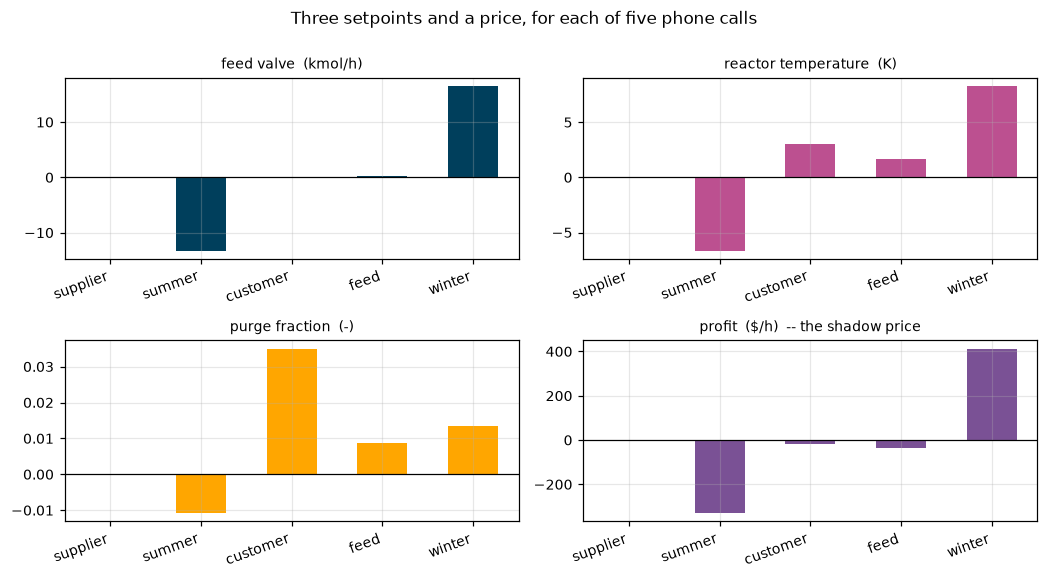

In [13]:
TAG  = [t.split(":")[0].split(" ")[0] for t, _, _ in SHIFT]
POS  = np.arange(len(SHIFT))
DXS  = np.array([J @ (np.eye(4)[PARAM.index(p)]*d) for _, p, d in SHIFT])
DPRF = np.array([DFDP[PARAM.index(p)]*d for _, p, d in SHIFT])

fig, ax = plt.subplots(2, 2, figsize=(9.6, 5.2))
panels = [(ax[0, 0], DXS[:, 0], "feed valve  (kmol/h)",  "#003f5c"),
          (ax[0, 1], DXS[:, 1], "reactor temperature  (K)", "#bc5090"),
          (ax[1, 0], DXS[:, 2], "purge fraction  (-)",   "#ffa600"),
          (ax[1, 1], DPRF,      "profit  ($/h)",         "#7a5195")]
for a, v, lab, c in panels:
    a.bar(POS, v, 0.55, color=c)
    a.axhline(0, color="k", lw=0.8)
    a.set_xticks(POS); a.set_xticklabels(TAG, rotation=20, ha="right")
    a.set_title(lab, fontsize=9)
ax[1, 1].set_title("profit  ($/h)  -- the shadow price", fontsize=9)
fig.suptitle("Three setpoints and a price, for each of five phone calls", y=1.0)
fig.tight_layout()

## 6. The counterintuitive mover

Cooling water de-rates 0.8 MW. Ask any experienced operator and the answer is
immediate: cooling is what is short, feed is what makes heat, so cut feed until
the duty fits. It is a good instinct, it is safe, and it is what the plant
would do.

Compare it against the delta plan.

In [14]:
DQ      = -0.8
PAR_SUM = PAR0 + np.array([0.0, DQ, 0.0, 0.0])
X_SUM, P_SUM = plan(PAR_SUM)

# what an experienced operator does: 15% less cooling, so cut feed 15%
lo, hi = 40.0, XB[0]
for _ in range(200):                        # back F off until cooling is met
    mid = 0.5*(lo + hi)
    if run_plant(mid, XB[1], XB[2], PAR0[3])["Q"] > PAR_SUM[1]: hi = mid
    else: lo = mid
NAIVE = (lo, XB[1], XB[2])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_DELTA = solution(sess0, [PIN["Q_max"]], [DQ])

print(f"{'':26s}{'F':>9s}{'T':>10s}{'y':>10s}  ->  {'P':>8s}{'pur':>9s}"
      f"{'$/h':>10s}   verdict")
rows = [("do nothing", XB[:3]), ("cut feed until cooling fits", NAIVE),
        ("delta plan", X_DELTA[:3]), ("full re-solve", X_SUM[:3])]
for tag, sp in rows:
    s = audit(sp[0], sp[1], sp[2], PAR_SUM)
    print(f"{tag:26s}{sp[0]:9.3f}{sp[1]:10.4f}{sp[2]:10.6f}  ->  "
          f"{s['P']:8.3f}{s['pur']:9.6f}{s['profit']:10.2f}   {s['verdict']}")

s_naive = audit(*NAIVE, PAR_SUM)
gap = P_SUM - s_naive["profit"]
print(f"\nholding T and y and cutting feed alone costs ${gap:.2f}/h, "
      f"${gap*8000:,.0f} over an 8000-hour season")
print(f"the purge valve moves {(X_SUM[2]-XB[2])/XB[2]*100:+.1f}% -- it CLOSES -- "
      f"while T moves {(X_SUM[1]-XB[1])/XB[1]*100:+.2f}%")

                                  F         T         y  ->         P      pur       $/h   verdict
do nothing                   86.766  553.2439  0.068479  ->    77.838 0.985000   2731.50   COOLING over by 0.800 MW
cut feed until cooling fits   72.262  553.2439  0.068479  ->    65.863 0.985016   2376.84   feasible
delta plan                   73.532  546.6049  0.057654  ->    66.812 0.984896   2393.98   OFF-SPEC by 104 ppm; COOLING over by 0.007 MW
full re-solve                73.503  546.0925  0.057462  ->    66.760 0.985000   2390.43   feasible

holding T and y and cutting feed alone costs $13.59/h, $108,731 over an 8000-hour season
the purge valve moves -16.1% -- it CLOSES -- while T moves -1.29%


The heuristic is feasible and loses `$13.59/h` — `$108,731` over an 8,000-hour
season — against a plan that costs one matrix–vector product.

And look at where the plan puts its money. The largest *fractional* move is not
on the feed at all: it is the **purge valve, which closes 16%**. Closing the
purge during a cooling shortage is not a move an operator reaches for — purge is
what protects purity, and purity is the other binding constraint. But cooling
duty falls with the purge fraction (a smaller bleed means less makeup feed for
the same production), so closing it buys duty, and the plan then spends part of
that duty on the feed it would otherwise have had to give up.

The same effect, sharper, on the specification disruption from section 2:

In [15]:
print(f"{'':10s}{'d/d(pur_min)':>16s}{'over +0.005':>14s}{'% of base':>12s}")
for n in SET + STATE:
    j = VNAMES.index(n)
    print(f"{n:10s}{J[j, 2]:16.4g}{J[j, 2]*0.005:14.4g}"
          f"{J[j, 2]*0.005/abs(XB[j])*100:11.1f}%")
print(f"\nnothing in the purity specification mentions the recycle compressor,")
print(f"and the compressor is where the largest fractional move lands.")

              d/d(pur_min)   over +0.005   % of base
F                   -37.29       -0.1865       -0.2%
T                    607.2         3.036        0.5%
y                    7.004       0.03502       51.1%
a                    -5585        -27.92      -20.3%
w                    -4134        -20.67      -38.0%
P                   -94.06       -0.4703       -0.6%
Q                1.213e-08     6.065e-11        0.0%
Rc                   -9682        -48.41      -46.0%
pur                      1         0.005        0.5%

nothing in the purity specification mentions the recycle compressor,
and the compressor is where the largest fractional move lands.


The customer's specification is a statement about the product stream. The
largest response to it is on the **recycle compressor**, a machine the
specification does not mention, three unit operations away, and the response is
to unload it by nearly half.

That is what a coupled model buys you. No amount of staring at the
specification produces "unload the compressor"; the Jacobian produces it in one
matrix–vector product.

Sweep the specification and the two views come apart completely:

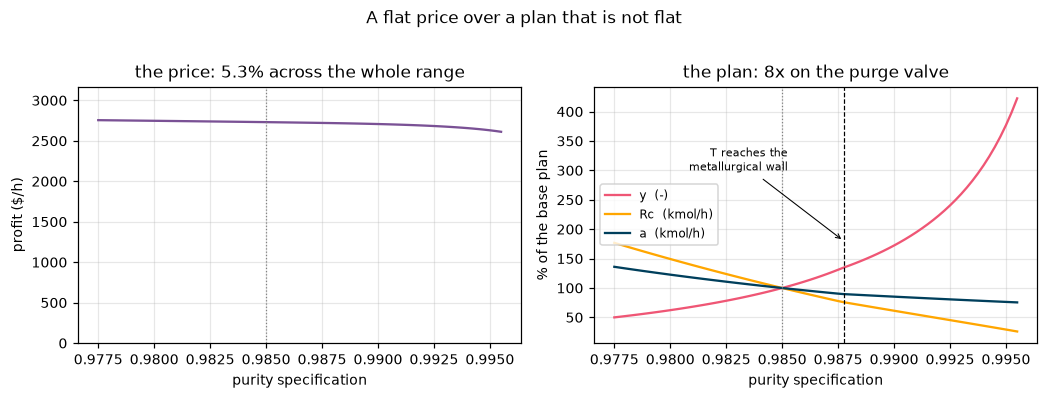

In [16]:
SPEC = np.arange(0.9775, 0.99551, 0.00025)
rows = np.array([np.concatenate([plan(PAR0 + [0, 0, s - PAR0[2], 0])[0][:9],
                                 [plan(PAR0 + [0, 0, s - PAR0[2], 0])[1]]])
                 for s in SPEC])
sat = SPEC[np.argmax(rows[:, 1] > T_UB - 1e-6)]      # where T reaches the wall

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))
ax[0].plot(SPEC, rows[:, 9], color="#7a5195")
ax[0].axvline(PAR0[2], color="0.5", lw=0.8, ls=":")
ax[0].set_xlabel("purity specification"); ax[0].set_ylabel("profit ($/h)")
ax[0].set_title(f"the price: {(rows[:,9].max()-rows[:,9].min())/PB*100:.1f}% "
                "across the whole range")
ax[0].set_ylim(0, rows[:, 9].max()*1.15)

for n, c in zip(["y", "Rc", "a"], ["#ef5675", "#ffa600", "#003f5c"]):
    j = VNAMES.index(n)
    ax[1].plot(SPEC, rows[:, j]/XB[j]*100, color=c, label=f"{n}  ({UNIT[n]})")
ax[1].axvline(PAR0[2], color="0.5", lw=0.8, ls=":")
ax[1].axvline(sat, color="k", lw=0.8, ls="--")
ax[1].annotate("T reaches the\nmetallurgical wall", xy=(sat, 180), fontsize=7.5,
               ha="right", xytext=(sat - 0.0025, 300),
               arrowprops=dict(arrowstyle="->", lw=0.7))
ax[1].set_xlabel("purity specification")
ax[1].set_ylabel("% of the base plan")
yc = rows[:, VNAMES.index("y")]
ax[1].set_title(f"the plan: {yc.max()/yc.min():.0f}x on the purge valve")
ax[1].legend(fontsize=8, loc="center left")
fig.suptitle("A flat price over a plan that is not flat", y=1.02)
fig.tight_layout()

## 7. When the delta is a lie

Everything so far has been the good case. Three of the five plans in section 5
failed their audit, and it is time to say why.

A linear step assumes the **active set does not change**: the same constraints
stay tight, the same bounds stay on, and the KKT system whose factorization you
are re-using is still the right system. When a constraint that was slack
becomes tight — or a variable reaches a bound — inside the requested move, that
assumption is false, and the step is a linearization of a problem that no
longer exists.

`solution_report` runs a ratio test against the same factorization and returns
`alpha`: the largest fraction of the requested move for which the active set
survives. `alpha >= 1` means the whole disruption is inside the region the
linearization describes. `alpha < 1` means it is not, and `first` / `first_kind`
name what breaks first.

It costs nothing extra. It is the same back-solve.

In [17]:
print(f"{'disruption':26s}{'alpha':>9s}{'first':>10s}{'kind':>12s}   crossed")
REP = {}
for tag, p, d in SHIFT:
    r = solution_report(sess0, [PIN[p]], [d])
    REP[tag] = r
    cr = ", ".join([f"{k}" for k in r.crossed] +
                   [f"{k} (row)" for k in r.crossed_rows]) or "-"
    print(f"{tag:26s}{r.alpha:9.4f}{str(r.first):>10s}{str(r.first_kind):>12s}   {cr}")
print("\nalpha is the fraction of the requested move the held active set survives.")
print("Above 1.0 the whole disruption is inside it; below 1.0 the plan is a")
print("linearization of a problem that has already changed shape.")

disruption                    alpha     first        kind   crossed
supplier short 5 kmol/h      2.6468  feed_cap  constraint   -
summer: cooling -0.8 MW      5.8638         y    variable   -
customer tightens spec       0.5784         T    variable   T
feed heavy 0.4 -> 0.8 %      1.0454         T    variable   -
winter: cooling +1.0 MW      0.2116         T    variable   T, feed_cap (row)

alpha is the fraction of the requested move the held active set survives.
Above 1.0 the whole disruption is inside it; below 1.0 the plan is a
linearization of a problem that has already changed shape.


Two of the five are already out of range before the plan is computed, and the
tightened specification — the disruption from section 2, the one that "costs
almost nothing" — is the worst of them at `alpha = 0.578`.

Here is what that means on the floor. The linear plan returns a full state
vector. Its `pur` entry reads exactly the new specification, because the
linearization is solving a system in which that row is tight. Run the plant at
the plan's three setpoints:

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_LIE = solution(sess0, [PIN["pur_min"]], [NEW_SPEC - PAR0[2]])

s_lie  = audit(X_LIE[0], X_LIE[1], X_LIE[2], PAR_SPEC)
s_true = audit(X_SPEC[0], X_SPEC[1], X_SPEC[2], PAR_SPEC)

print(f"{'':22s}{'F':>9s}{'T':>10s}{'y':>10s} | {'purity it':>11s}{'purity it':>11s}")
print(f"{'':22s}{'':9s}{'':10s}{'':10s} | {'predicts':>11s}{'delivers':>11s}   verdict")
for tag, xs, s in (("delta plan", X_LIE, s_lie), ("full re-solve", X_SPEC, s_true)):
    print(f"{tag:22s}{xs[0]:9.3f}{xs[1]:10.4f}{xs[2]:10.6f} | "
          f"{xs[8]:11.6f}{s['pur']:11.6f}   {s['verdict']}")
print(f"\nthe delta plan's own purity entry reads {X_LIE[8]:.6f} -- exactly the new "
      f"spec.\nRun the plant at its three setpoints and the product comes out at "
      f"{s_lie['pur']:.6f}.")
print(f"alpha for this move was {REP['customer tightens spec'].alpha:.4f}: the "
      f"warning was there before the plan was.")

                              F         T         y |   purity it  purity it
                                                    |    predicts   delivers   verdict
delta plan               86.580  555.0000  0.103501 |    0.990000   0.988844   OFF-SPEC by 1,156 ppm
full re-solve            86.990  555.0000  0.118004 |    0.990000   0.990000   feasible

the delta plan's own purity entry reads 0.990000 -- exactly the new spec.
Run the plant at its three setpoints and the product comes out at 0.988844.
alpha for this move was 0.5784: the warning was there before the plan was.


Off-spec by 1,156 ppm, at line rate, into a product tank, with
nothing in the answer to say so. The linear step's own purity entry is a
*prediction from a model that has changed*, not a measurement, and it is wrong
in the direction that costs money.

The other failure is the opposite shape. Cooling capacity *improves* by 1.0 MW
in winter — good news, more room — and the plan happily spends it:

In [19]:
DQ_W    = 1.0
PAR_W   = PAR0 + np.array([0.0, DQ_W, 0.0, 0.0])
X_W, P_W = plan(PAR_W)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_WLIN = solution(sess0, [PIN["Q_max"]], [DQ_W])
r = REP["winter: cooling +1.0 MW"]

print(f"{'':22s}{'F':>9s}{'T':>10s}{'y':>10s}{'$/h':>10s}   verdict")
for tag, xs in (("delta plan", X_WLIN), ("full re-solve", X_W)):
    s = audit(xs[0], xs[1], xs[2], PAR_W)
    print(f"{tag:22s}{xs[0]:9.3f}{xs[1]:10.4f}{xs[2]:10.6f}{s['profit']:10.2f}"
          f"   {s['verdict']}")
print(f"\nreport: alpha={r.alpha:.4f}  first={r.first} ({r.first_kind})")
print(f"        crossed variables: "
      f"{ {k: round(v, 4) for k, v in r.crossed.items()} }")
print(f"        crossed rows:      "
      f"{ {k: round(v, 4) for k, v in r.crossed_rows.items()} }")
for c in active_set_changes(sess0, [PIN["Q_max"]], [DQ_W]):
    print(f"        change at fraction {c.fraction:.4f}: "
          f"{c.var} {c.action} its {c.bound} bound")
print(f"\nthe plan asks for {X_WLIN[0]:.2f} kmol/h of feed against a "
      f"{PAR_W[0]:.0f} kmol/h contract,")
print(f"and books ${audit(*X_WLIN[:3], PAR_W)['profit'] - P_W:+.2f}/h of profit "
      f"that is not available.")

                              F         T         y       $/h   verdict
delta plan              103.309  555.0000  0.082011   3053.22   CONTRACT over by 3.31 kmol/h
full re-solve           100.000  555.0000  0.071458   3013.19   feasible

report: alpha=0.2116  first=T (variable)
        crossed variables: {'T': 6.5427}
        crossed rows:      {'feed_cap': 3.309}
        change at fraction 0.2116: T reaches its upper bound

the plan asks for 103.31 kmol/h of feed against a 100 kmol/h contract,
and books $+40.04/h of profit that is not available.


The plan asks for 103.31 kmol/h of feed against a 100 kmol/h contract. The
constraint it violates is not one that was binding at the base point at all:
`feed_cap` was slack by 13.2 kmol/h, the column for $F_{\max}$ was identically
zero, and the ratio test still found it — `crossed_rows` reports the row and by
how much, and `active_set_changes` reports that $T$ reaches its upper bound at
21% of the way in.

And the profit it books, `$3,053/h`, is `$40/h` above what is actually available.
A plan that is optimistic about a resource you do not have is worse than no
plan; it is a plan with a number attached that will be defended in a meeting.

**Does one of the other modes rescue it?** `solution` takes `mode="fix_relax"`
(pin the crossings and re-solve the reduced system) and `mode="path"` (walk the
active-set changes one at a time). On the specification disruption:

In [20]:
D_SPEC = NEW_SPEC - PAR0[2]
print(f"{'mode':12s}{'F':>9s}{'T':>10s}{'y':>10s}{'purity delivered':>18s}   verdict")
for mode in ("linear", "fix_relax", "path"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xm = solution(sess0, [PIN["pur_min"]], [D_SPEC], mode=mode)
    s = audit(xm[0], xm[1], xm[2], PAR_SPEC)
    print(f"{mode:12s}{xm[0]:9.3f}{xm[1]:10.4f}{xm[2]:10.6f}{s['pur']:18.6f}   "
          f"{s['verdict']}")
print(f"{'re-solve':12s}{X_SPEC[0]:9.3f}{X_SPEC[1]:10.4f}{X_SPEC[2]:10.6f}"
      f"{s_true['pur']:18.6f}   {s_true['verdict']}")
for c in active_set_changes(sess0, [PIN["pur_min"]], [D_SPEC]):
    print(f"\nactive_set_changes: at fraction {c.fraction:.4f}, "
          f"{c.var} {c.action} its {c.bound} bound")

mode                F         T         y  purity delivered   verdict
linear         86.580  555.0000  0.103501          0.988844   OFF-SPEC by 1,156 ppm
fix_relax      86.907  555.0000  0.101435          0.988657   OFF-SPEC by 1,343 ppm; COOLING over by 0.007 MW
path           86.907  555.0000  0.101435          0.988657   OFF-SPEC by 1,343 ppm; COOLING over by 0.007 MW
re-solve       86.990  555.0000  0.118004          0.990000   feasible

active_set_changes: at fraction 0.5784, T reaches its upper bound


They do not. Both modes move the purge to 0.1014 against a true 0.1180, and
both still ship off-spec. This is worth being precise about: **the guard tells
you the plan is untrustworthy; it does not hand you a trustworthy plan.** Those
are different services, and conflating them is how a guard gets ignored.

## 8. The corrector

There is one more thing to try, and it is the one that works. `corrector_iter`
runs Newton iterations on the barrier system *at the predicted point*, using the
held factorization as the preconditioner — so it is still back-solves, still no
re-solve, and it repairs the linearization error rather than the active set.

On the summer de-rate, where `alpha = 5.86` and the only error is curvature:

In [21]:
print(f"{'corrector_iter':16s}{'F':>10s}{'T':>11s}{'y':>11s}"
      f"{'purity delivered':>18s}{'$/h':>10s}")
for ci in (0, 1, 2, 3):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xm = solution(sess0, [PIN["Q_max"]], [DQ_INTRO], corrector_iter=ci)
    s = audit(xm[0], xm[1], xm[2], PAR_Q)
    print(f"{ci:<16d}{xm[0]:10.4f}{xm[1]:11.5f}{xm[2]:11.7f}{s['pur']:18.7f}"
          f"{s['profit']:10.2f}   {s['verdict']}")
print(f"{'re-solve':16s}{X_Q[0]:10.4f}{X_Q[1]:11.5f}{X_Q[2]:11.7f}"
      f"{PAR_Q[2]:18.7f}{P_Q:10.2f}")
rep = solution_report(sess0, [PIN["Q_max"]], [DQ_INTRO], corrector_iter=2)
c = rep.corrector
print(f"\ncorrector: {c['iterations']} back-solves, residual "
      f"{c['initial_residual']:.3e} -> {c['residual']:.3e}, "
      f"converged={c['converged']}")

corrector_iter           F          T          y  purity delivered       $/h
0                  73.5317  546.60489  0.0576539         0.9848961   2393.98   OFF-SPEC by 104 ppm; COOLING over by 0.007 MW
1                  73.5026  546.09394  0.0574563         0.9849984   2390.45   OFF-SPEC by 2 ppm
2                  73.5027  546.09244  0.0574624         0.9850000   2390.43   feasible
3                  73.5027  546.09245  0.0574625         0.9850000   2390.43   feasible
re-solve           73.5027  546.09245  0.0574625         0.9850000   2390.43

corrector: 2 back-solves, residual 3.349e+01 -> 2.416e-03, converged=False


Two back-solves and the plan matches the full re-solve to six digits, purity
lands exactly on specification, and the audit comes back clean. The residual
falls from 33.5 to 2.4e-3 and `converged` is still `False` — the corrector
reports honestly that it stopped on the iteration budget, not on a tolerance,
which is the right thing to look at rather than the answer's plausibility.

Now the same call on the specification disruption, where `alpha = 0.578`:

In [22]:
print(f"{'corrector_iter':16s}{'F':>10s}{'T':>11s}{'y':>11s}"
      f"{'purity delivered':>18s}   verdict")
for ci in (0, 2, 5):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xm = solution(sess0, [PIN["pur_min"]], [D_SPEC], corrector_iter=ci)
    s = audit(xm[0], xm[1], xm[2], PAR_SPEC)
    print(f"{ci:<16d}{xm[0]:10.4f}{xm[1]:11.5f}{xm[2]:11.7f}{s['pur']:18.7f}   "
          f"{s['verdict']}")
print(f"{'re-solve':16s}{X_SPEC[0]:10.4f}{X_SPEC[1]:11.5f}{X_SPEC[2]:11.7f}"
      f"{s_true['pur']:18.7f}   {s_true['verdict']}")

corrector_iter           F          T          y  purity delivered   verdict
0                  86.5796  555.00000  0.1035010         0.9888444   OFF-SPEC by 1,156 ppm
2                  86.5796  555.00000  0.1035010         0.9888444   OFF-SPEC by 1,156 ppm
5                  86.5796  555.00000  0.1035010         0.9888444   OFF-SPEC by 1,156 ppm
re-solve           86.9898  555.00000  0.1180044         0.9900000   feasible


Nothing moves. Not at 2 iterations, not at 5.

That is the boundary, and it is the useful lesson of this section. The
corrector fixes **curvature**: the error you make by taking a straight step
along a curved manifold. It cannot fix a **changed active set**, because the
system it is iterating on is the wrong system — $T$ is pinned at its bound in
the corrector's KKT matrix, and no number of Newton steps on that matrix will
discover that the true answer wants a different purge fraction with $T$ pinned
*and* the purity row re-balanced around it. When `alpha < 1`, the answer is to
re-solve. `alpha` is what tells you which of the two situations you are in, and
it costs one ratio test.

Sweep the cooling disruption over its whole range and the two regimes are
visible as one picture:

alpha >= 1 over dQ in [-4.638, +0.200] MW -- 23x wider on the down side than the up side

|profit error|              linear   corrected
inside  (alpha >= 1)         13.51        0.02
outside (alpha <  1)         23.93       23.44

inside the region the corrector removes the error entirely; outside it,
two more back-solves buy almost nothing, because the active set moved.


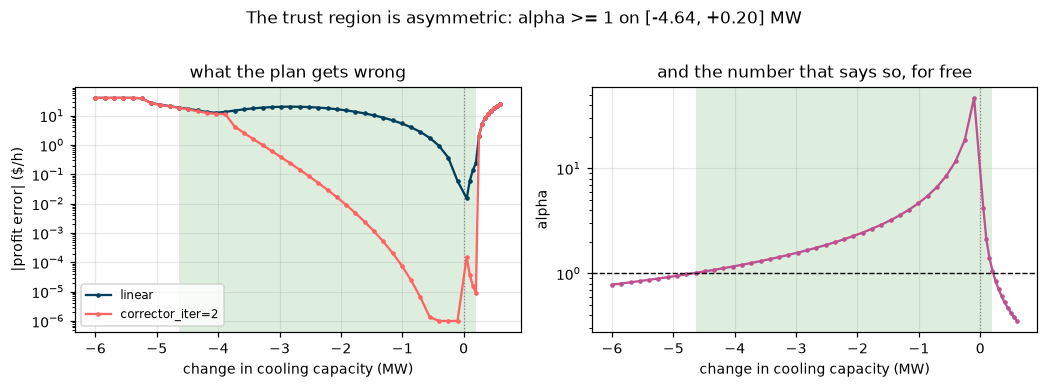

In [23]:
DQ_SWEEP = np.concatenate([np.linspace(-6.0, -0.1, 40), np.linspace(0.05, 0.6, 12)])
err, ecor, alph = [], [], []
# at the far end of the de-rate the clamped plan drives the recycle loop to
# zero holdup, which is a division by zero in the *plant* simulation, not in
# anything POUNCE returned -- the profit it reports there is still finite
for d in DQ_SWEEP:
    par = PAR0 + np.array([0.0, d, 0.0, 0.0])
    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")
        xl = solution(sess0, [PIN["Q_max"]], [d])
        xc = solution(sess0, [PIN["Q_max"]], [d], corrector_iter=2)
        alph.append(solution_report(sess0, [PIN["Q_max"]], [d]).alpha)
    p_true = plan(par)[1]
    with np.errstate(all="ignore"):
        err.append(abs(audit(xl[0], xl[1], xl[2], par)["profit"] - p_true))
        ecor.append(abs(audit(xc[0], xc[1], xc[2], par)["profit"] - p_true))
alph, err, ecor = np.array(alph), np.array(err), np.array(ecor)
assert np.isfinite(err).all() and np.isfinite(ecor).all()
lo, hi = DQ_SWEEP[alph >= 1.0].min(), DQ_SWEEP[alph >= 1.0].max()

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4), sharex=True)
for a in ax:
    a.axvspan(lo, hi, color="#7fbf7f", alpha=0.25, lw=0)
    a.axvline(0, color="0.5", lw=0.8, ls=":")
    a.set_xlabel("change in cooling capacity (MW)")
ax[0].semilogy(DQ_SWEEP, np.maximum(err, 1e-6), ".-", ms=4, color="#003f5c",
               label="linear")
ax[0].semilogy(DQ_SWEEP, np.maximum(ecor, 1e-6), ".-", ms=4, color="#ff6361",
               label="corrector_iter=2")
ax[0].legend(fontsize=8)
ax[0].set_ylabel("|profit error| ($/h)")
ax[0].set_title("what the plan gets wrong")
ax[1].semilogy(DQ_SWEEP, alph, ".-", ms=4, color="#bc5090")
ax[1].axhline(1.0, color="k", lw=0.9, ls="--")
ax[1].set_ylabel("alpha")
ax[1].set_title("and the number that says so, for free")
fig.suptitle(f"The trust region is asymmetric: alpha >= 1 on "
             f"[{lo:+.2f}, {hi:+.2f}] MW", y=1.02)
fig.tight_layout()

ins = (DQ_SWEEP >= lo) & (DQ_SWEEP <= hi)
print(f"alpha >= 1 over dQ in [{lo:+.3f}, {hi:+.3f}] MW -- "
      f"{abs(lo)/hi:.0f}x wider on the down side than the up side")
print(f"\n{'|profit error|':22s}{'linear':>12s}{'corrected':>12s}")
for tag, m in (("inside  (alpha >= 1)", ins), ("outside (alpha <  1)", ~ins)):
    print(f"{tag:22s}{np.median(err[m]):12.2f}{np.median(ecor[m]):12.2f}")
print("\ninside the region the corrector removes the error entirely; outside it,")
print("two more back-solves buy almost nothing, because the active set moved.")

Two things in one picture. The trust region is **asymmetric**: `alpha >= 1`
from −4.64 MW to +0.20 MW, a factor of 23. Losing cooling is safe to plan
linearly almost all the way to
half capacity; *gaining* it runs into the feed contract within a fifth of a
megawatt. Nothing about the shadow price, which is a single number, distinguishes
those two directions.

And the corrector's curve is the section above, measured across the whole
sweep. Inside the region it takes the median profit error from `$13.51/h` to
**`$0.02/h`** — two back-solves and the linearization error is gone. Outside it,
the same two back-solves take `$23.93/h` to `$23.44/h`: nothing. `alpha` is the
line between "repairable without a solve" and "go and solve it".

## 9. Deltas do not compose

The specification tightens **and** the supplier ships heavier feed. Two
disruptions, two plans already computed, and the obvious move is to add them.

The linear steps genuinely do superpose — that is what linear means, and the
cell below verifies it to 5e-7. The plant does not.

In [24]:
DA = np.array([0.0, 0.0, 0.005, 0.000])      # customer tightens the spec
DB = np.array([0.0, 0.0, 0.000, 0.004])      # supplier ships heavier feed

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    xa = solution(sess0, [PIN["pur_min"]], [DA[2]])
    xb = solution(sess0, [PIN["z_w"]],     [DB[3]])
    xj = solution(sess0, [PIN["pur_min"], PIN["z_w"]], [DA[2], DB[3]])
    ua = solution(sess0, [PIN["pur_min"]], [DA[2]], clamp=False)
    ub = solution(sess0, [PIN["z_w"]],     [DB[3]], clamp=False)
    uj = solution(sess0, [PIN["pur_min"], PIN["z_w"]], [DA[2], DB[3]], clamp=False)
    ra = solution_report(sess0, [PIN["pur_min"]], [DA[2]])
    rb = solution_report(sess0, [PIN["z_w"]],     [DB[3]])
    rj = solution_report(sess0, [PIN["pur_min"], PIN["z_w"]], [DA[2], DB[3]])
X_JT, P_JT = plan(PAR0 + DA + DB)
sup = XB + (ua - XB) + (ub - XB)            # "just add the two plans"

print(f"{'':26s}{'F':>9s}{'T':>10s}{'y':>10s}   verdict")
for tag, sp in (("spec plan alone",     xa[:3]),
                ("feed plan alone",     xb[:3]),
                ("the two plans added", sup[:3]),
                ("joint delta plan",     uj[:3]),
               ("the same, clamped",    xj[:3]),
                ("joint re-solve",      X_JT[:3])):
    s = audit(sp[0], sp[1], sp[2], PAR0 + DA + DB)
    print(f"{tag:26s}{sp[0]:9.3f}{sp[1]:10.4f}{sp[2]:10.6f}   {s['verdict']}")

print(f"\nthe linear steps superpose exactly (by construction): "
      f"max|added - joint| = {np.abs((ua - XB) + (ub - XB) - (uj - XB)).max():.3e}")
print(f"the plant does not. The added plan asks for T = {sup[1]:.2f} K against a "
      f"{T_UB:.0f} K wall,\nwhile the true joint answer is T = {X_JT[1]:.2f} K.")
print(f"\nalpha:  spec alone {ra.alpha:.4f}   feed alone {rb.alpha:.4f}   "
      f"jointly {rj.alpha:.4f}")
print("the joint trust region is shorter than either one -- so two moves that are")
print("each inside their own range can be outside their range together.")

                                  F         T         y   verdict
spec plan alone              86.580  555.0000  0.103501   OFF-SPEC by 1,884 ppm
feed plan alone              87.017  554.9238  0.077213   OFF-SPEC by 5,011 ppm; COOLING over by 0.001 MW
the two plans added          86.830  557.9597  0.112235   OFF-SPEC by 1,674 ppm; COOLING over by 0.016 MW; METALLURGY over by 2.96 K
joint delta plan             86.830  557.9597  0.112235   OFF-SPEC by 1,674 ppm; COOLING over by 0.016 MW; METALLURGY over by 2.96 K
the same, clamped            86.830  555.0000  0.112235   OFF-SPEC by 1,112 ppm
joint re-solve               87.664  555.0000  0.127209   feasible

the linear steps superpose exactly (by construction): max|added - joint| = 4.885e-07
the plant does not. The added plan asks for T = 557.96 K against a 555 K wall,
while the true joint answer is T = 555.00 K.

alpha:  spec alone 0.5784   feed alone 1.0454   jointly 0.3724
the joint trust region is shorter than either one -- so two m

Each plan alone is a plan you might ship. Added together they ask for
557.96 K against a 555 K wall — 2.96 K into the reactor's metallurgical limit,
which is a mechanical-integrity question, not an economic one.

And the joint `alpha` is **0.372**, shorter than either disruption's own
(0.578 and 1.045). Trust regions do not compose either: two moves that are each
inside their own range can be well outside their range together, and the joint
ratio test is a different back-solve, not the minimum of two you already have.

(`solution` will clamp the returned point back inside the bounds if you let it.
Note what that does here: it silently truncates $T$ to 555.0 and hands back a
plan that looks feasible and is not the answer. The clamp is a convenience for
staying in the box, never evidence that the step was valid.)

## 10. The fractional plan

The plan says move the temperature −6.639 K. The DCS accepts increments of
0.5 K. The feed valve moves in 0.5 kmol/h steps, and the purge setpoint in
0.002. So the plan that gets executed is never the plan that was computed, and
the question is which way to round.

"Nearest" is the obvious rule and it is the wrong one:

In [25]:
INC = np.array([0.5, 0.5, 0.002])            # what the DCS will actually accept
DX  = (X_DELTA - XB)[:3]                     # the exact continuous plan

def grid(v, rule):                           # rule per knob: -1 down, +1 up, 0 near
    q = np.asarray(v)/INC
    f = np.where(rule < 0, np.floor(q), np.where(rule > 0, np.ceil(q), np.round(q)))
    return INC*f

# purity rises with y and falls with F and T, and cooling rises with both of
# those -- so "protective" means round F and T down and y up
NEAR = grid(DX, np.zeros(3))
PROT = grid(DX, np.array([-1, -1, +1]))

def at(d):
    return audit(XB[0] + d[0], XB[1] + d[1], XB[2] + d[2], PAR_SUM)

print(f"{'plan':30s}{'dF':>8s}{'dT':>8s}{'dy':>10s}{'$/h':>10s}{'vs exact':>10s}"
      f"   verdict")
base = at(DX)["profit"]
for tag, d in (("exact (continuous)", DX), ("nearest increment", NEAR),
               ("protective (F, T down; y up)", PROT)):
    s = at(d)
    print(f"{tag:30s}{d[0]:8.3f}{d[1]:8.3f}{d[2]:10.5f}{s['profit']:10.2f}"
          f"{s['profit']-base:10.2f}   {s['verdict']}")

best, bd = -1e30, None
for i in range(-6, 7):
    for j in range(-6, 7):
        for k in range(-6, 7):
            d = NEAR + INC*np.array([i, j, k])
            s = at(d)
            if s["verdict"] == "feasible" and s["profit"] > best:
                best, bd = s["profit"], d
print(f"\n{'best feasible grid point':30s}{bd[0]:8.3f}{bd[1]:8.3f}{bd[2]:10.5f}"
      f"{best:10.2f}{best-base:10.2f}   feasible")

h = np.array([1e-3, 1e-3, 1e-5])
def gp(key):
    return np.array([(run_plant(*(XB[:3] + np.eye(3)[i]*h[i]), PAR0[3])[key]
                      - run_plant(*(XB[:3] - np.eye(3)[i]*h[i]), PAR0[3])[key])
                     / (2*h[i]) for i in range(3)])
print(f"\nplant gradients at the base point (which way each knob pushes)")
print(f"{'':14s}{'d/dF':>12s}{'d/dT':>12s}{'d/dy':>12s}")
for key in ("pur", "Q"):
    g = gp(key)
    print(f"{key:14s}{g[0]:12.3e}{g[1]:12.3e}{g[2]:12.3e}")
print("\ncooling rises with F and T, so round those DOWN; purity rises with y, "
      "and\nso -- helpfully -- does cooling headroom, so round y UP. That rule "
      "is not a\nheuristic: it is the sign pattern of the two rows the plan is "
      "up against.")

plan                                dF      dT        dy       $/h  vs exact   verdict
exact (continuous)             -13.234  -6.639  -0.01083   2393.98      0.00   OFF-SPEC by 104 ppm; COOLING over by 0.007 MW
nearest increment              -13.000  -6.500  -0.01000   2399.58      5.60   COOLING over by 0.021 MW
protective (F, T down; y up)   -13.500  -7.000  -0.01000   2384.65     -9.33   feasible



best feasible grid point       -13.000  -8.500  -0.01200   2388.54     -5.44   feasible

plant gradients at the base point (which way each knob pushes)
                      d/dF        d/dT        d/dy
pur             -1.214e-06  -2.683e-04   1.660e-01
Q                5.358e-02   1.541e-02  -1.051e+00

cooling rises with F and T, so round those DOWN; purity rises with y, and
so -- helpfully -- does cooling headroom, so round y UP. That rule is not a
heuristic: it is the sign pattern of the two rows the plan is up against.


Rounding to the nearest increment moves *less* than asked on the two knobs that
buy cooling headroom, and the plan lands 0.021 MW over the condenser — an alarm
on a unit that was the reason for the whole exercise. It even reports a
*higher* profit than the exact plan, which is exactly what an infeasible point
does.

The rule that works is not a heuristic. Round each knob in the direction that
relieves the constraints the plan is up against, read off the sign pattern of
the binding rows' gradients: cooling rises with $F$ and $T$, so round those
**down**; purity rises with $y$ (and so, helpfully, does cooling headroom), so
round $y$ **up**. That is feasible on the first try, and it costs `$5.79/h`
against the continuous optimum — where a search over 2,197 nearby grid points
finds `$1.89/h` is the best any rounded plan can do.

## 11. What this cost, in dollars

One disruption — the summer cooling de-rate — priced four ways, all of them
audited by running the plant, none of them predictions.

In [26]:
HOURS = 8000.0
ROWS = [("the true re-solve (continuous)",     P_SUM),
        ("delta plan, best feasible rounding",  best),
        ("delta plan, protective rounding",     at(PROT)["profit"]),
        ("cut feed until cooling fits",         s_naive["profit"])]
print(f"{'summer de-rate: -0.8 MW of cooling':40s}{'$/h':>10s}{'vs optimum':>12s}"
      f"{'per 8000 h':>14s}")
for tag, v in ROWS:
    print(f"{tag:40s}{v:10.2f}{v-P_SUM:12.2f}{(v-P_SUM)*HOURS:14,.0f}")
print("\n(the nearest-increment plan is not in this table: it is infeasible, and "
      "an\nover-duty condenser is an alarm, not a line item)")

print(f"\nwhat the answers cost to produce")
print(f"  one full re-solve, per disruption      {t_solve*1e3:8.2f} ms")
print(f"  the Jacobian, once, for all of them    {t_jac*1e3:8.2f} ms")
print(f"  each disruption after that             {t_mv*1e6:8.2f} us")
print(f"\nThe cheap part was never the arithmetic -- a 2 ms re-solve was never the "
      f"reason\nnobody re-planned. It is that the plan is on the screen before "
      f"the phone call\nends, and that alpha says, in the same breath, whether it "
      f"is a plan or a guess.")

summer de-rate: -0.8 MW of cooling             $/h  vs optimum    per 8000 h
the true re-solve (continuous)             2390.43        0.00             0
delta plan, best feasible rounding         2388.54       -1.89       -15,128
delta plan, protective rounding            2384.65       -5.79       -46,312
cut feed until cooling fits                2376.84      -13.59      -108,731

(the nearest-increment plan is not in this table: it is infeasible, and an
over-duty condenser is an alarm, not a line item)

what the answers cost to produce
  one full re-solve, per disruption          2.27 ms
  the Jacobian, once, for all of them        0.09 ms
  each disruption after that                 0.39 us

The cheap part was never the arithmetic -- a 2 ms re-solve was never the reason
nobody re-planned. It is that the plan is on the screen before the phone call
ends, and that alpha says, in the same breath, whether it is a plan or a guess.


## Summary

* **A shadow price tells you what a disruption costs; the delta planning
  vector tells you what to do about it, and it comes from the same
  factorization.** The tightened specification here costs 0.86% of margin, and
  the plan that defends it moves the purge valve +72% and the recycle
  compressor −39%. Reading the price and stopping is how a small number becomes
  an off-spec tank.

* **Four back-solves buy the whole playbook.** $\partial x^\star/\partial p$
  for four parameters took under 0.15 ms — more than 20× less than one re-solve —
  and every disruption after that is a matrix–vector product costing well under
  a microsecond. The economic
  argument is not the arithmetic (a 2 ms re-solve was never the bottleneck);
  it is that the plan is on the screen before the phone call ends.

* **The largest mover is routinely a unit the disruption never mentions.** A
  cooling shortage *closes* the purge valve; a product specification unloads a
  compressor three unit operations upstream. In a recycle loop no knob has a
  local effect, and the coupled answer is not guessable from the disruption's
  own units.

* **The delta is sometimes a lie, and it lies while reporting success.** The
  specification plan returns a state vector whose purity entry reads exactly
  0.990000 and whose setpoints deliver 0.988844. The winter plan books `$40/h`
  on 3.31 kmol/h of feed the contract forbids. Neither answer contains a
  warning — but `solution_report`'s `alpha` (0.578 and 0.212) is the same
  back-solve, and it is a *precondition* on trusting the plan, not a
  post-check.

* **`alpha` separates the two failures, and only one of them is repairable
  without a solve.** Above 1, the error is curvature, and `corrector_iter=2`
  reached the true re-solve to six digits. Below 1, the active set has changed,
  and the corrector moved *nothing* — its KKT matrix is the wrong matrix.
  `fix_relax` and `path` did not rescue it either. The guard says the plan is
  untrustworthy; it does not produce a trustworthy plan. Re-solve.

* **Neither deltas nor their trust regions compose.** Two plans that superpose
  exactly as vectors sum to a request 2.96 K above the reactor's metallurgical
  limit, and the joint `alpha` (0.372) is shorter than either disruption's own
  (0.578, 1.045). A joint disruption is a different back-solve.

* **The plan that gets executed is rounded, and the rounding direction is a
  sign pattern, not a preference.** Nearest-increment rounding landed 0.021 MW
  over the condenser while reporting a higher profit. Rounding each knob toward
  the binding rows cost `$5.79/h` against the continuous optimum; the
  experienced operator's heuristic — hold $T$ and $y$, cut feed until the duty
  fits — cost `$13.59/h`, or `$108,731` a season.

**Related:** [`40_shadow_prices_expire.ipynb`](40_shadow_prices_expire.ipynb)
(how far a *price* holds, from the same ratio test),
[`04_sensitivity.ipynb`](04_sensitivity.ipynb),
[`36_active_set_parametric_sensitivity.ipynb`](36_active_set_parametric_sensitivity.ipynb)
(the same machinery inside a closed loop, with the update policies and the
fallback guards),
[`39_design_under_kinetic_uncertainty.ipynb`](39_design_under_kinetic_uncertainty.ipynb),
and [`docs/src/sensitivity.md`](../../docs/src/sensitivity.md).